In [1]:
import accelforge as af
from scheduling.scheduler import *
from af_wrapper import *
import numpy as np


def run(
    einsums,
    compute_units,
    data_dependencies,
    latency_per_component_grid = None,
    total_latency_grid = None,
    actions_grid = None,
    memory_name = None,
    shared_memory_info = None,
):
    schedule, min_latency = best_schedule(
        einsums,
        compute_units,
        shared_memory_info,
        data_dependencies,
        latency_per_component_grid,
        total_latency_grid,
        actions_grid,
        memory_name
    )
    return schedule, min_latency


In [2]:
# Toy example. This only works with the non-resource-aware scheduler,
# which takes a grid of latencies as inputs rather than mappings
toy_data_dependencies = {
    "e1": [],
    "e2": [],
    "e3": ["e1", "e2"]
}
toy_compute_units = ['slow', 'fast']
toy_einsums = toy_data_dependencies.keys()
toy_grid = {
    ('slow', 'e1'): 0.2,
    ('fast', 'e1'): 0.1,
    ('slow', 'e2'): 0.1,
    ('fast', 'e2'): 0.05,
    ('slow', 'e3'): 0.2,
    ('fast', 'e3'): 0.1,
}
run(
    toy_einsums,
    toy_compute_units,
    toy_data_dependencies,
    total_latency_grid=toy_grid)

({(e1, fast, latency=0.1): 0,
  (e2, slow, latency=0.1): 0,
  (e3, fast, latency=0.1): 0.1},
 0.2)

In [3]:
arch = "arch/eyeriss-submods/full.yaml"
m2_workload = "workload/milestone-2/m2-full.yaml"

In [22]:
spec = af.Spec.from_yaml(
    arch,
    "workload/gpt_v.yaml" #m2_workload
)

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 1/1 [00:00<00:00,  4.21it/s]
Generating jobs:   0%|          | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute SlowMAC Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute SlowMAC Einsum V: 16it [00:00, 82.83it/s][A

Generating pmapping templates for compute FastMAC Einsum V: 0it [00:00, ?it/s]
Generating pmapping templates for compute FastMAC Einsum V: 16it [00:00, 80.62it/s][A
Generating jobs: 100%|██████████| 1/1 [00:00<00:00,  2.24it/s]


Einsum V has 32 pmapping jobs:
	0	[WV in MainMemory] [V in MainMemory] [Iv in MainMemory] T-b  T-d  T-m  S-reuse_output-d  S-reuse_weight-m  S-reuse_weight-b  [Iv in SlowInputScratchpad] T-e  T-h  [WV in SlowWeightScratchpad] T-b  T-m  [V in SlowOutputScratchpad] T-d  SlowMAC computes V
	1	[WV in MainMemory] [V in MainMemory] [Iv in MainMemory] T-b  T-d  T-m  [Iv in SlowGlobalBuffer] S-reuse_output-d  S-reuse_weight-m  S-reuse_weight-b  [Iv in SlowInputScratchpad] T-e  T-h  [WV in SlowWeightScratchpad] T-b  T-m  [V in SlowOutputScratchpad] T-d  SlowMAC computes V
	2	[WV in MainMemory] [V in MainMemory] [Iv in MainMemory] T-b  T-e  T-h  T-m  [V in SlowGlobalBuffer] T-d  S-reuse_output-d  S-reuse_weight-m  S-reuse_weight-b  [Iv in SlowInputScratchpad] T-e  T-h  [WV in SlowWeightScratchpad] T-b  T-m  [V in SlowOutputScratchpad] T-d  SlowMAC computes V
	3	[WV in MainMemory] [V in MainMemory] [Iv in MainMemory] T-d  T-e  T-h  [WV in SlowGlobalBuffer] T-b  T-m  S-reuse_output-d  S-reuse_weig

Compressing pmappings: 100%|██████████| 1/1 [00:00<00:00, 291.19it/s]


Dirty joining with resource usage <= 1.2× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 1/1 [00:00<00:00, 1006.31it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=6.24e-01
Final clean join.


Dirty pruning pmappings: 100%|██████████| 1/1 [00:00<00:00, 1288.18it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|██████████| 1/1 [00:00<00:00, 8905.10it/s]


Dirty joining mapping(s) valid & optimal! Returning...


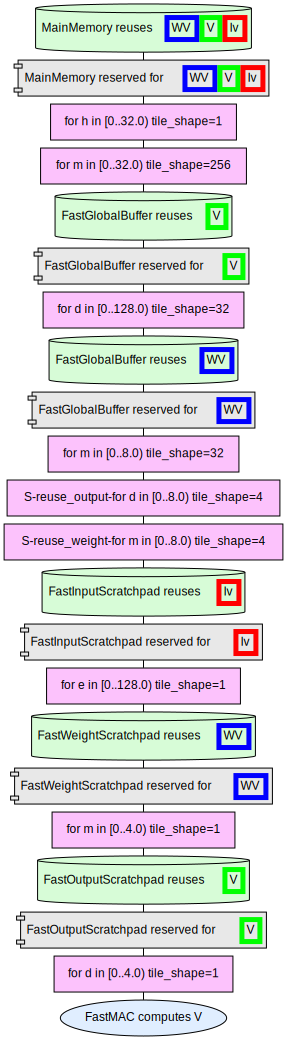

In [24]:
spec.map_workload_to_arch()

In [6]:
# m2_full_mapping = af_map(
#     "arch/eyeriss-submods/full.yaml",
#     "workload/milestone-2/m2-full.yaml"
# )

In [7]:
# mappings = []
# for i in range(5):
#     filename = trunc(arch) + "-" + trunc(m2_workload) + "-" + str(i)
#     with open("images/" + filename + ".svg", "w") as f:
#         f.write(m2_full_mapping[i].render())
#     mappings.append(process_mapping(arch, m2_workload, m2_full_mapping[i]))

# # m2_full_mapping.to_dict()
# mappings

In [8]:
data_dependencies = {
    "E0": [],
    "E1": [],
    "E2": ["E0"],
    "E3": ["E0", "E1"], # weirdly we get a cycle if we have a different dep graph where E3 not dep on E0
    "E4": ["E2", "E3"]
}
compute_units = ['slow', 'fast']
einsums = data_dependencies.keys()
memory_name = "MainMemory"

In [9]:
%%capture grid_output

# RUN TO GENERATE ACCELFORGE VALUES.
# To skip recomputation when running with fresh kernel, comment out
# this cell and use the below assignments instead.

# (grid_lats, grid_mems, grid_maps) = af_memoizable_grid(
#     einsums, 
#     compute_units,
#     lambda einsum: "workload/milestone-2/"+einsum+".yaml",
#     lambda sub_arch: "arch/eyeriss-submods/"+sub_arch+".yaml"
# )

In [10]:
# grid_lats

In [11]:
# grid_mems

In [12]:
# # MEMOIZED VALUES:
grid_lats = {('slow', 'E0'): {'SlowMAC': np.float32(0.00049152),
  'SlowInputScratchpad': np.float32(9.278403e-05),
  'MainMemory': np.float32(6.144e-05),
  'SlowWeightScratchpad': np.float32(3.3454155e-05),
  'SlowGlobalBuffer': np.float32(4.16e-06),
  'SlowOutputScratchpad': np.float32(0.00021865385)},
 ('slow', 'E1'): {'SlowMAC': np.float32(3.84e-06),
  'SlowInputScratchpad': np.float32(1.4385121e-06),
  'MainMemory': np.float32(2.08e-05),
  'SlowWeightScratchpad': np.float32(3.136327e-07),
  'SlowGlobalBuffer': np.float32(4.5e-08),
  'SlowOutputScratchpad': np.float32(1.4385121e-06)},
 ('slow', 'E2'): {'SlowMAC': np.float32(0.00049152),
  'SlowInputScratchpad': np.float32(9.278403e-05),
  'MainMemory': np.float32(6.144e-05),
  'SlowOutputScratchpad': np.float32(0.00021865385),
  'SlowGlobalBuffer': np.float32(4.16e-06),
  'SlowWeightScratchpad': np.float32(3.3454155e-05)},
 ('slow', 'E3'): {'SlowMAC': np.float32(3.84e-06),
  'SlowInputScratchpad': np.float32(1.4385121e-06),
  'MainMemory': np.float32(2.08e-05),
  'SlowWeightScratchpad': np.float32(3.136327e-07),
  'SlowGlobalBuffer': np.float32(4.5e-08),
  'SlowOutputScratchpad': np.float32(1.4385121e-06)},
 ('slow', 'E4'): {'SlowMAC': np.float32(3.84e-06),
  'SlowInputScratchpad': np.float32(1.4385121e-06),
  'MainMemory': np.float32(2.08e-05),
  'SlowOutputScratchpad': np.float32(1.4385121e-06),
  'SlowGlobalBuffer': np.float32(4.5e-08),
  'SlowWeightScratchpad': np.float32(3.136327e-07)},
 ('fast', 'E0'): {'FastMAC': np.float32(0.00016384),
  'FastInputScratchpad': np.float32(9.278403e-05),
  'MainMemory': np.float32(6.144e-05),
  'FastWeightScratchpad': np.float32(5.3526648e-05),
  'FastGlobalBuffer': np.float32(5.44e-06),
  'FastOutputScratchpad': np.float32(0.00018412955)},
 ('fast', 'E1'): {'FastMAC': np.float32(1.28e-06),
  'FastInputScratchpad': np.float32(1.4385121e-06),
  'MainMemory': np.float32(2.08e-05),
  'FastWeightScratchpad': np.float32(3.136327e-07),
  'FastGlobalBuffer': np.float32(4.5e-08),
  'FastOutputScratchpad': np.float32(1.4385121e-06)},
 ('fast', 'E2'): {'FastMAC': np.float32(0.00016384),
  'FastInputScratchpad': np.float32(9.278403e-05),
  'MainMemory': np.float32(6.144e-05),
  'FastOutputScratchpad': np.float32(0.00018412955),
  'FastGlobalBuffer': np.float32(5.44e-06),
  'FastWeightScratchpad': np.float32(5.3526648e-05)},
 ('fast', 'E3'): {'FastMAC': np.float32(1.28e-06),
  'FastInputScratchpad': np.float32(1.4385121e-06),
  'MainMemory': np.float32(2.08e-05),
  'FastWeightScratchpad': np.float32(3.136327e-07),
  'FastGlobalBuffer': np.float32(4.5e-08),
  'FastOutputScratchpad': np.float32(1.4385121e-06)},
 ('fast', 'E4'): {'FastMAC': np.float32(1.28e-06),
  'FastInputScratchpad': np.float32(1.4385121e-06),
  'MainMemory': np.float32(2.08e-05),
  'FastOutputScratchpad': np.float32(1.4385121e-06),
  'FastGlobalBuffer': np.float32(4.5e-08),
  'FastWeightScratchpad': np.float32(3.136327e-07)}}
grid_mems = {('slow', 'E0'): {('SlowInputScratchpad', 'read'): np.float64(16777216.0),
  ('SlowInputScratchpad', 'write'): np.float32(131072.0),
  ('MainMemory', 'read'): np.float64(262144.0),
  ('MainMemory', 'write'): np.float64(131072.0),
  ('SlowWeightScratchpad', 'read'): np.float64(16777216.0),
  ('SlowWeightScratchpad', 'write'): np.float32(4.194304e+06),
  ('SlowGlobalBuffer', 'read'): np.float32(16384.0),
  ('SlowGlobalBuffer', 'write'): np.float32(10240.0),
  ('SlowOutputScratchpad', 'read'): np.float32(1.9922944e+07),
  ('SlowOutputScratchpad', 'write'): np.float32(1.9922944e+07),
  ('SlowMAC', 'compute'): np.float64(2097152.0)},
 ('slow', 'E1'): {('SlowInputScratchpad', 'read'): np.float64(131072.0),
  ('SlowInputScratchpad', 'write'): np.float32(131072.0),
  ('MainMemory', 'read'): np.float64(132096.0),
  ('MainMemory', 'write'): np.float64(1024.0),
  ('SlowWeightScratchpad', 'read'): np.float64(131072.0),
  ('SlowWeightScratchpad', 'write'): np.float32(65536.0),
  ('SlowGlobalBuffer', 'read'): np.float32(144.0),
  ('SlowGlobalBuffer', 'write'): np.float32(144.0),
  ('SlowOutputScratchpad', 'read'): np.float32(131072.0),
  ('SlowOutputScratchpad', 'write'): np.float32(131072.0),
  ('SlowMAC', 'compute'): np.float64(16384.0)},
 ('slow', 'E2'): {('SlowInputScratchpad', 'read'): np.float64(16777216.0),
  ('SlowInputScratchpad', 'write'): np.float32(131072.0),
  ('MainMemory', 'read'): np.float64(262144.0),
  ('MainMemory', 'write'): np.float64(131072.0),
  ('SlowOutputScratchpad', 'read'): np.float32(1.9922944e+07),
  ('SlowOutputScratchpad', 'write'): np.float32(1.9922944e+07),
  ('SlowGlobalBuffer', 'read'): np.float32(16384.0),
  ('SlowGlobalBuffer', 'write'): np.float32(10240.0),
  ('SlowWeightScratchpad', 'read'): np.float64(16777216.0),
  ('SlowWeightScratchpad', 'write'): np.float32(4.194304e+06),
  ('SlowMAC', 'compute'): np.float64(2097152.0)},
 ('slow', 'E3'): {('SlowInputScratchpad', 'read'): np.float64(131072.0),
  ('SlowInputScratchpad', 'write'): np.float32(131072.0),
  ('MainMemory', 'read'): np.float64(132096.0),
  ('MainMemory', 'write'): np.float64(1024.0),
  ('SlowWeightScratchpad', 'read'): np.float64(131072.0),
  ('SlowWeightScratchpad', 'write'): np.float32(65536.0),
  ('SlowGlobalBuffer', 'read'): np.float32(144.0),
  ('SlowGlobalBuffer', 'write'): np.float32(144.0),
  ('SlowOutputScratchpad', 'read'): np.float32(131072.0),
  ('SlowOutputScratchpad', 'write'): np.float32(131072.0),
  ('SlowMAC', 'compute'): np.float64(16384.0)},
 ('slow', 'E4'): {('SlowInputScratchpad', 'read'): np.float64(131072.0),
  ('SlowInputScratchpad', 'write'): np.float32(131072.0),
  ('MainMemory', 'read'): np.float64(132096.0),
  ('MainMemory', 'write'): np.float64(1024.0),
  ('SlowOutputScratchpad', 'read'): np.float32(131072.0),
  ('SlowOutputScratchpad', 'write'): np.float32(131072.0),
  ('SlowGlobalBuffer', 'read'): np.float32(144.0),
  ('SlowGlobalBuffer', 'write'): np.float32(144.0),
  ('SlowWeightScratchpad', 'read'): np.float64(131072.0),
  ('SlowWeightScratchpad', 'write'): np.float32(65536.0),
  ('SlowMAC', 'compute'): np.float64(16384.0)},
 ('fast', 'E0'): {('FastInputScratchpad', 'read'): np.float64(16777216.0),
  ('FastInputScratchpad', 'write'): np.float32(131072.0),
  ('MainMemory', 'read'): np.float64(262144.0),
  ('MainMemory', 'write'): np.float64(131072.0),
  ('FastWeightScratchpad', 'read'): np.float64(16777216.0),
  ('FastWeightScratchpad', 'write'): np.float32(1.6777216e+07),
  ('FastGlobalBuffer', 'read'): np.float32(32768.0),
  ('FastGlobalBuffer', 'write'): np.float32(2048.0),
  ('FastOutputScratchpad', 'read'): np.float32(1.6777216e+07),
  ('FastOutputScratchpad', 'write'): np.float32(1.6777216e+07),
  ('FastMAC', 'compute'): np.float64(2097152.0)},
 ('fast', 'E1'): {('FastInputScratchpad', 'read'): np.float64(131072.0),
  ('FastInputScratchpad', 'write'): np.float32(131072.0),
  ('MainMemory', 'read'): np.float64(132096.0),
  ('MainMemory', 'write'): np.float64(1024.0),
  ('FastWeightScratchpad', 'read'): np.float64(131072.0),
  ('FastWeightScratchpad', 'write'): np.float32(65536.0),
  ('FastGlobalBuffer', 'read'): np.float32(144.0),
  ('FastGlobalBuffer', 'write'): np.float32(144.0),
  ('FastOutputScratchpad', 'read'): np.float32(131072.0),
  ('FastOutputScratchpad', 'write'): np.float32(131072.0),
  ('FastMAC', 'compute'): np.float64(16384.0)},
 ('fast', 'E2'): {('FastInputScratchpad', 'read'): np.float64(16777216.0),
  ('FastInputScratchpad', 'write'): np.float32(131072.0),
  ('MainMemory', 'read'): np.float64(262144.0),
  ('MainMemory', 'write'): np.float64(131072.0),
  ('FastOutputScratchpad', 'read'): np.float32(1.6777216e+07),
  ('FastOutputScratchpad', 'write'): np.float32(1.6777216e+07),
  ('FastGlobalBuffer', 'read'): np.float32(32768.0),
  ('FastGlobalBuffer', 'write'): np.float32(2048.0),
  ('FastWeightScratchpad', 'read'): np.float64(16777216.0),
  ('FastWeightScratchpad', 'write'): np.float32(1.6777216e+07),
  ('FastMAC', 'compute'): np.float64(2097152.0)},
 ('fast', 'E3'): {('FastInputScratchpad', 'read'): np.float64(131072.0),
  ('FastInputScratchpad', 'write'): np.float32(131072.0),
  ('MainMemory', 'read'): np.float64(132096.0),
  ('MainMemory', 'write'): np.float64(1024.0),
  ('FastWeightScratchpad', 'read'): np.float64(131072.0),
  ('FastWeightScratchpad', 'write'): np.float32(65536.0),
  ('FastGlobalBuffer', 'read'): np.float32(144.0),
  ('FastGlobalBuffer', 'write'): np.float32(144.0),
  ('FastOutputScratchpad', 'read'): np.float32(131072.0),
  ('FastOutputScratchpad', 'write'): np.float32(131072.0),
  ('FastMAC', 'compute'): np.float64(16384.0)},
 ('fast', 'E4'): {('FastInputScratchpad', 'read'): np.float64(131072.0),
  ('FastInputScratchpad', 'write'): np.float32(131072.0),
  ('MainMemory', 'read'): np.float64(132096.0),
  ('MainMemory', 'write'): np.float64(1024.0),
  ('FastOutputScratchpad', 'read'): np.float32(131072.0),
  ('FastOutputScratchpad', 'write'): np.float32(131072.0),
  ('FastGlobalBuffer', 'read'): np.float32(144.0),
  ('FastGlobalBuffer', 'write'): np.float32(144.0),
  ('FastWeightScratchpad', 'read'): np.float64(131072.0),
  ('FastWeightScratchpad', 'write'): np.float32(65536.0),
  ('FastMAC', 'compute'): np.float64(16384.0)}}

In [13]:
# for (key, mapping) in grid_maps.items():
#     print(mapping.latency(per_component=True))
#     print("Overall latency:", mapping.latency(per_einsum=True))
#     print()
#     print()

In [14]:
schedule, latency = run(
    einsums,
    compute_units,
    data_dependencies,
    latency_per_component_grid = grid_lats,
    actions_grid = grid_mems,
    memory_name = memory_name,
    # shared_memory_info = {} # TODO I'm a dummy just to see everything still typechecks
) 

In [15]:
schedule

{(E0, fast, latency=0.0001841295452322811): 0,
 (E2, fast, latency=0.0001841295452322811): np.float64(0.0001841295452322811),
 (E1, slow, latency=3.121614456520912e-05): 0,
 (E3, slow, latency=3.121614456520912e-05): np.float64(0.0001841295452322811),
 (E4, slow, latency=2.080000012938399e-05): np.float64(0.0003682590904645622)}

In [16]:
latency

np.float64(0.00038905909059394617)

In [17]:
mems = sum(
    sum(
        count
        for (action, count) in grid_mems[(node.compute_assignment, node.einsum_name)].items()
        if action[0] == memory_name
    ) 
    for node in schedule.keys()
)
mems

np.float64(1185792.0)

In [18]:
# bwu
(mems/latency) / 6.4e9 # old schedule: np.float64(0.4762258443913986)

np.float64(0.47622585997707306)

In [21]:
# Testing architecture pairing gen
generate_architecture_pairings(
    ['c1', 'c2', 'c3'],
    {'m1' : [(1, 2, 3), (5, 10, 15)],
     'm2' : [(7, 14, 21), (11, 22, 33)]})

[('c1', ('m1', 1), ('m2', 7)),
 ('c1', ('m1', 1), ('m2', 11)),
 ('c1', ('m1', 5), ('m2', 7)),
 ('c1', ('m1', 5), ('m2', 11)),
 ('c2', ('m1', 2), ('m2', 14)),
 ('c2', ('m1', 2), ('m2', 22)),
 ('c2', ('m1', 10), ('m2', 14)),
 ('c2', ('m1', 10), ('m2', 22)),
 ('c3', ('m1', 3), ('m2', 21)),
 ('c3', ('m1', 3), ('m2', 33)),
 ('c3', ('m1', 15), ('m2', 21)),
 ('c3', ('m1', 15), ('m2', 33))]